# Notebook 01 — Data Preparation, Exploratory Data Analysis and Multimodal LLM Description

## Assignment 3: AI Imaging Coding Case Study

This notebook completes the data preparation, exploratory data analysis (EDA), and multimodal image-description stage of the imaging pipeline.

The notebook covers:

1. Dataset extraction and structural auditing.
2. Image and mask correspondence checks.
3. Image resolution, channel and intensity profiling.
4. Grayscale conversion and resizing to 256 × 256 pixels.
5. Visual EDA using representative images and intensity histograms.
6. PyTorch dataset and DataLoader verification for the later U-Net pipeline.
7. Local multimodal LLM inference using Ollama and `llama3.2-vision`.
8. Comparison of a naive image-description prompt with an optimised structured prompt.
9. JSON schema validation.
10. Repeated VLM runs to demonstrate output variability.

### Important preprocessing decision

The Task 1 VLM/EDA workflow uses grayscale 256 × 256 images as required by the assignment.

The existing U-Net pipeline is kept as a separate RGB 256 × 256 pipeline because the U-Net developed in the later notebook uses three input channels. This avoids changing the already-developed segmentation architecture while still satisfying the Task 1 grayscale requirement.

In [20]:
import os
import zipfile
import glob
import json
import base64
import hashlib
import requests

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader


# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

# Keep the exact paths from the original Notebook 1
DATA_ZIP = r"C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\nuclei_dataset.zip"

EXTRACT_DIR = r"C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw"

OUTPUT_FIG_DIR = r"C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\figures"

# Additional output folders using the same original project location
OUTPUT_DATA_DIR = r"C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\data"

OUTPUT_LLM_DIR = r"C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\llm"


# Create output directories if they do not already exist
os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(OUTPUT_DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_LLM_DIR, exist_ok=True)


# Standard image size required by the assignment
TARGET_SIZE = (256, 256)


# Ollama configuration
OLLAMA_URL = "http://localhost:11434/api/chat"
VLM_MODEL = "qwen2.5vl:latest"


# Reproducibility
np.random.seed(42)


print("Environment initialized successfully.")
print("Dataset ZIP:", DATA_ZIP)
print("Extraction directory:", EXTRACT_DIR)
print("Figure output directory:", OUTPUT_FIG_DIR)
print("Data output directory:", OUTPUT_DATA_DIR)
print("LLM output directory:", OUTPUT_LLM_DIR)
print("Target image size:", TARGET_SIZE)
print("VLM model:", VLM_MODEL)

Environment initialized successfully.
Dataset ZIP: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\nuclei_dataset.zip
Extraction directory: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw
Figure output directory: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\figures
Data output directory: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\data
LLM output directory: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\llm
Target image size: (256, 256)
VLM model: qwen2.5vl:latest


## 1. Dataset Extraction and Directory Audit

The dataset is extracted from the supplied ZIP archive and its directory structure is checked before any image processing is performed.

The expected structure is:

```text
nuclei_dataset/
├── train/
│   ├── images/
│   └── masks/
├── val/
│   ├── images/
│   └── masks/
└── test/
    ├── images/
    └── masks/

In [3]:

def inspect_and_extract_zip(zip_path, extract_to):
    """
    Extract the dataset ZIP archive if necessary and audit
    the number of images and masks in each split.

    Parameters
    ----------
    zip_path : str
        Path to the dataset ZIP file.
    extract_to : str
        Directory where the dataset will be extracted.

    Returns
    -------
    dataset_dir : str
        Root directory of the extracted dataset.
    structure_summary : dict
        Image and mask counts for each split.
    """

    expected_root = os.path.join(
        extract_to,
        "nuclei_dataset"
    )

    # Extract only if the dataset has not already been extracted
    if not os.path.exists(expected_root):

        print(f"Extracting dataset to:\n{extract_to}")

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_to)

        print("Extraction completed.")

    else:
        print("Dataset already extracted. Skipping extraction.")

    # Use nuclei_dataset if present, otherwise use extraction directory
    if os.path.exists(expected_root):
        dataset_dir = expected_root
    else:
        dataset_dir = extract_to

    structure_summary = {}

    for split in ["train", "val", "test"]:

        image_dir = os.path.join(
            dataset_dir,
            split,
            "images"
        )

        mask_dir = os.path.join(
            dataset_dir,
            split,
            "masks"
        )

        image_files = sorted(
            glob.glob(os.path.join(image_dir, "*.png"))
        )

        mask_files = sorted(
            glob.glob(os.path.join(mask_dir, "*.png"))
        )

        structure_summary[split] = {
            "images": len(image_files),
            "masks": len(mask_files)
        }

    return dataset_dir, structure_summary


dataset_root, counts = inspect_and_extract_zip(
    DATA_ZIP,
    EXTRACT_DIR
)


print("\n" + "=" * 60)
print("DATASET HIERARCHY AUDIT")
print("=" * 60)

for split, split_counts in counts.items():

    print(
        f"{split:<6} | "
        f"Images: {split_counts['images']:<4} | "
        f"Masks: {split_counts['masks']:<4}"
    )

Dataset already extracted. Skipping extraction.

DATASET HIERARCHY AUDIT
train  | Images: 80   | Masks: 80  
val    | Images: 20   | Masks: 20  
test   | Images: 12   | Masks: 12  


## 2. Image–Mask Correspondence Check

For segmentation, each image must have a corresponding ground-truth mask.

The correspondence is checked using filenames rather than relying only on the order returned by the operating system. This reduces the risk of pairing an image with the wrong mask.

In [4]:
def check_file_correspondence(dataset_dir, split):
    """
    Check whether image and mask filenames correspond.

    Returns
    -------
    missing_masks : set
        Image IDs for which a mask is missing.
    missing_images : set
        Mask IDs for which an image is missing.
    """

    image_dir = os.path.join(
        dataset_dir,
        split,
        "images"
    )

    mask_dir = os.path.join(
        dataset_dir,
        split,
        "masks"
    )

    image_names = {
        os.path.splitext(os.path.basename(path))[0]
        for path in glob.glob(
            os.path.join(image_dir, "*.png")
        )
    }

    mask_names = {
        os.path.splitext(os.path.basename(path))[0]
        for path in glob.glob(
            os.path.join(mask_dir, "*.png")
        )
    }

    missing_masks = image_names - mask_names
    missing_images = mask_names - image_names

    print(f"\n{split.upper()} CORRESPONDENCE CHECK")
    print("-" * 50)
    print(f"Images without masks: {len(missing_masks)}")
    print(f"Masks without images: {len(missing_images)}")

    if missing_masks:
        print("Missing masks:", sorted(missing_masks))

    if missing_images:
        print("Missing images:", sorted(missing_images))

    return missing_masks, missing_images


for split in ["train", "val", "test"]:
    check_file_correspondence(
        dataset_root,
        split
    )


TRAIN CORRESPONDENCE CHECK
--------------------------------------------------
Images without masks: 0
Masks without images: 0

VAL CORRESPONDENCE CHECK
--------------------------------------------------
Images without masks: 0
Masks without images: 0

TEST CORRESPONDENCE CHECK
--------------------------------------------------
Images without masks: 0
Masks without images: 0


## 3. Dataset Image Properties and Class Balance

Basic image properties are calculated to establish the characteristics of the dataset before modelling.

The analysis records:

- image resolution,
- number of colour channels,
- minimum and maximum intensity,
- mean and standard deviation of intensity,
- foreground/nuclei proportion,
- background proportion.

The foreground proportion is particularly important because nuclei occupy only a relatively small part of each image. This creates a class-imbalance problem for segmentation and motivates the use of Dice-based evaluation and loss functions in the later U-Net pipeline.

In [5]:
def analyze_image_properties(
    dataset_dir,
    split="train",
    sample_size=None
):
    """
    Calculate image dimensions, channel counts,
    intensity statistics and foreground ratios.

    Parameters
    ----------
    dataset_dir : str
        Dataset root.
    split : str
        Dataset split.
    sample_size : int or None
        Number of images to inspect. None uses all images.

    Returns
    -------
    dict
        Dataset statistics.
    """

    img_dir = os.path.join(
        dataset_dir,
        split,
        "images"
    )

    mask_dir = os.path.join(
        dataset_dir,
        split,
        "masks"
    )

    img_files = sorted(
        glob.glob(
            os.path.join(img_dir, "*.png")
        )
    )

    mask_lookup = {
        os.path.splitext(os.path.basename(path))[0]: path
        for path in glob.glob(
            os.path.join(mask_dir, "*.png")
        )
    }

    if sample_size is not None:
        img_files = img_files[:sample_size]

    shapes = []
    channels = []
    raw_pixel_vals = []
    foreground_ratios = []

    for img_path in img_files:

        image_rgb = np.array(
            Image.open(img_path).convert("RGB")
        )

        image_gray = np.array(
            Image.open(img_path).convert("L")
        )

        shapes.append(image_gray.shape)

        channels.append(
            image_rgb.shape[-1]
        )

        # Subsample pixels to reduce memory usage
        raw_pixel_vals.extend(
            image_gray.ravel()[::100]
        )

        image_id = os.path.splitext(
            os.path.basename(img_path)
        )[0]

        if image_id in mask_lookup:

            mask = np.array(
                Image.open(
                    mask_lookup[image_id]
                ).convert("L")
            )

            foreground_ratios.append(
                np.mean(mask > 0)
            )

    mean_fg = (
        np.mean(foreground_ratios)
        if foreground_ratios
        else 0.0
    )

    bg_ratio = 1.0 - mean_fg

    statistics = {
        "resolutions": sorted(set(shapes)),
        "channels": sorted(set(channels)),
        "min_intensity": float(np.min(raw_pixel_vals)),
        "max_intensity": float(np.max(raw_pixel_vals)),
        "mean_intensity": float(np.mean(raw_pixel_vals)),
        "std_intensity": float(np.std(raw_pixel_vals)),
        "foreground_ratio": float(mean_fg),
        "background_ratio": float(bg_ratio)
    }

    return statistics


image_stats = analyze_image_properties(
    dataset_root,
    split="train"
)


print("\n" + "=" * 60)
print("IMAGE PROPERTY SUMMARY")
print("=" * 60)

print(
    "Unique resolutions:",
    image_stats["resolutions"]
)

print(
    "Channel depth:",
    image_stats["channels"]
)

print(
    f"Minimum intensity: "
    f"{image_stats['min_intensity']:.1f}"
)

print(
    f"Maximum intensity: "
    f"{image_stats['max_intensity']:.1f}"
)

print(
    f"Mean intensity: "
    f"{image_stats['mean_intensity']:.2f}"
)

print(
    f"Standard deviation: "
    f"{image_stats['std_intensity']:.2f}"
)

print(
    f"Nuclei / foreground: "
    f"{image_stats['foreground_ratio'] * 100:.2f}%"
)

print(
    f"Background: "
    f"{image_stats['background_ratio'] * 100:.2f}%"
)


IMAGE PROPERTY SUMMARY
Unique resolutions: [(256, 256)]
Channel depth: [3]
Minimum intensity: 0.0
Maximum intensity: 90.0
Mean intensity: 9.34
Standard deviation: 18.33
Nuclei / foreground: 8.18%
Background: 91.82%


## 4. Task 1 Preprocessing — Grayscale and 256 × 256

The assignment requires the images to be converted to grayscale and resized to a common size of 256 × 256 pixels.

A dedicated preprocessing function is therefore used for the Task 1 EDA and VLM workflow:

**Original image → grayscale → 256 × 256 pixels**

The processed representative image is saved to disk so that the exact image used for the VLM experiment can be reproduced.

The later U-Net notebook retains the RGB input pipeline because the existing U-Net architecture expects three input channels.

In [6]:
def preprocess_for_task1(
    image_path,
    target_size=(256, 256)
):
    """
    Convert an image to grayscale and resize it.

    Parameters
    ----------
    image_path : str
        Path to the original image.
    target_size : tuple
        Target (width, height).

    Returns
    -------
    PIL.Image
        Grayscale resized image.
    """

    image = Image.open(
        image_path
    ).convert("L")

    image = image.resize(
        target_size,
        Image.BILINEAR
    )

    return image


def save_task1_image(
    image_path,
    output_path,
    target_size=(256, 256)
):
    """
    Preprocess a single image and save it.
    """

    image = preprocess_for_task1(
        image_path,
        target_size
    )

    image.save(output_path)

    return image


train_image_dir = os.path.join(
    dataset_root,
    "train",
    "images"
)

train_images = sorted(
    glob.glob(
        os.path.join(
            train_image_dir,
            "*.png"
        )
    )
)


# Use the first training image as the representative image
# so that the experiment is reproducible.
REPRESENTATIVE_INDEX = 0

representative_original_path = train_images[
    REPRESENTATIVE_INDEX
]

representative_output_path = os.path.join(
    OUTPUT_DATA_DIR,
    "representative_grayscale_256.png"
)


representative_gray = save_task1_image(
    representative_original_path,
    representative_output_path,
    TARGET_SIZE
)


print("Representative original image:")
print(representative_original_path)

print("\nProcessed image:")
print(representative_output_path)

print("\nProcessed size:")
print(representative_gray.size)

print("\nImage mode:")
print(representative_gray.mode)

Representative original image:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\train\images\train_000.png

Processed image:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\data\representative_grayscale_256.png

Processed size:
(256, 256)

Image mode:
L


## 5. Visual EDA and Intensity Histograms

A compact EDA figure is produced for use in both the notebook and the final report.

The figure contains:

- representative RGB images,
- grayscale representation,
- ground-truth masks,
- raw grayscale intensity histogram,
- min-max normalised intensity histogram,
- nuclei overlay.

The histogram provides a basic view of image intensity distribution, while the mask and overlay provide visual context for the segmentation problem.

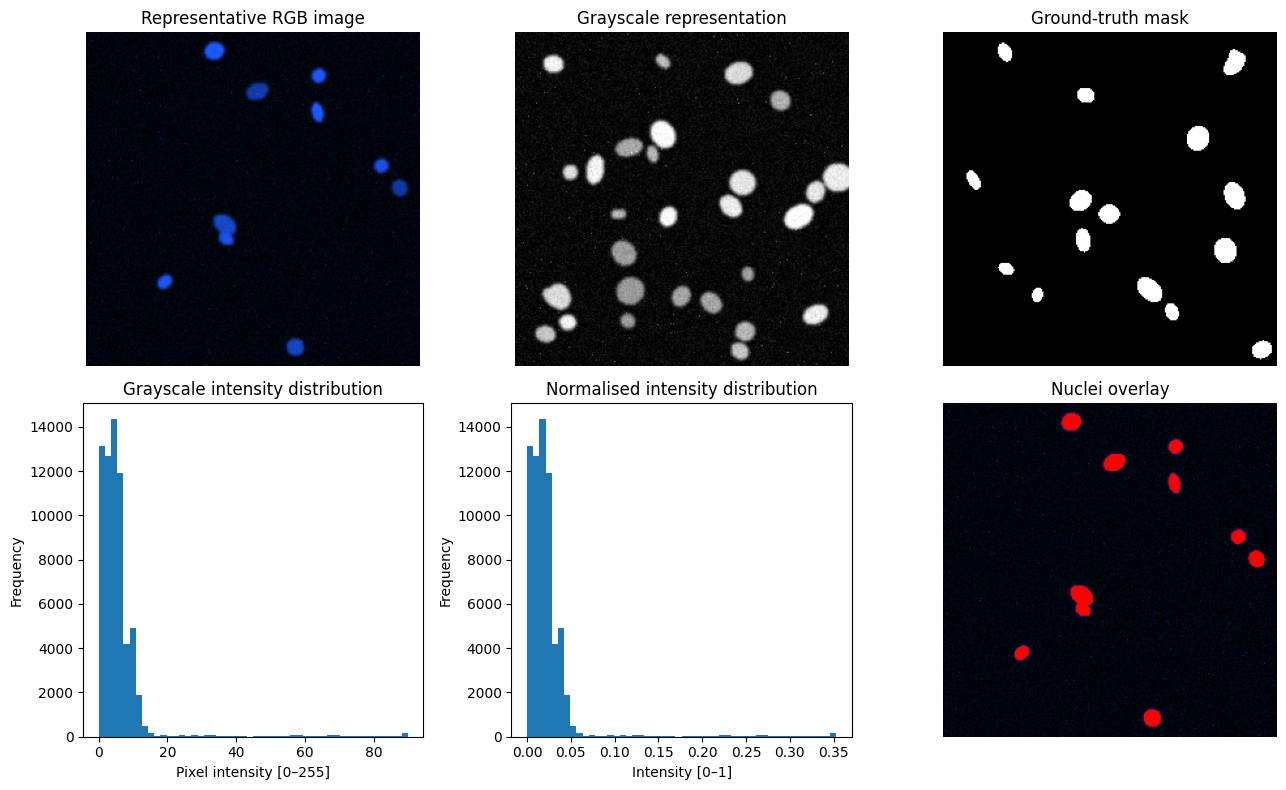

EDA figure saved to:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\figures\eda_summary.png


In [7]:
def create_eda_figure(
    dataset_dir,
    output_path
):
    """
    Create and save a compact EDA figure.

    The figure contains sample images, masks,
    intensity histograms and a nuclei overlay.
    """

    img_dir = os.path.join(
        dataset_dir,
        "train",
        "images"
    )

    mask_dir = os.path.join(
        dataset_dir,
        "train",
        "masks"
    )

    img_files = sorted(
        glob.glob(
            os.path.join(img_dir, "*.png")
        )
    )

    mask_lookup = {
        os.path.splitext(os.path.basename(path))[0]: path
        for path in glob.glob(
            os.path.join(mask_dir, "*.png")
        )
    }

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(13, 8)
    )

    # --------------------------------------------------------
    # Three representative images
    # --------------------------------------------------------

    for i in range(3):

        image_path = img_files[i]

        image_id = os.path.splitext(
            os.path.basename(image_path)
        )[0]

        rgb = np.array(
            Image.open(image_path).convert("RGB")
        )

        gray = np.array(
            Image.open(image_path).convert("L")
        )

        mask = np.array(
            Image.open(
                mask_lookup[image_id]
            ).convert("L")
        )

        if i == 0:

            axes[0, i].imshow(rgb)
            axes[0, i].set_title(
                "Representative RGB image"
            )

        elif i == 1:

            axes[0, i].imshow(
                gray,
                cmap="gray"
            )

            axes[0, i].set_title(
                "Grayscale representation"
            )

        else:

            axes[0, i].imshow(
                mask,
                cmap="gray"
            )

            axes[0, i].set_title(
                "Ground-truth mask"
            )

        axes[0, i].axis("off")

    # --------------------------------------------------------
    # Raw grayscale histogram
    # --------------------------------------------------------

    sample_gray = np.array(
        Image.open(
            img_files[0]
        ).convert("L")
    )

    axes[1, 0].hist(
        sample_gray.ravel(),
        bins=50
    )

    axes[1, 0].set_title(
        "Grayscale intensity distribution"
    )

    axes[1, 0].set_xlabel(
        "Pixel intensity [0–255]"
    )

    axes[1, 0].set_ylabel(
        "Frequency"
    )

    # --------------------------------------------------------
    # Normalised histogram
    # --------------------------------------------------------

    normalised = (
        sample_gray.astype(np.float32)
        / 255.0
    )

    axes[1, 1].hist(
        normalised.ravel(),
        bins=50
    )

    axes[1, 1].set_title(
        "Normalised intensity distribution"
    )

    axes[1, 1].set_xlabel(
        "Intensity [0–1]"
    )

    axes[1, 1].set_ylabel(
        "Frequency"
    )

    # --------------------------------------------------------
    # Ground-truth overlay
    # --------------------------------------------------------

    rgb = np.array(
        Image.open(
            img_files[0]
        ).convert("RGB")
    )

    mask = np.array(
        Image.open(
            mask_lookup[
                os.path.splitext(
                    os.path.basename(img_files[0])
                )[0]
            ]
        ).convert("L")
    )

    overlay = rgb.copy()

    # Highlight nuclei pixels
    overlay[mask > 0] = [255, 0, 0]

    axes[1, 2].imshow(overlay)

    axes[1, 2].set_title(
        "Nuclei overlay"
    )

    axes[1, 2].axis("off")

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "EDA figure saved to:"
    )

    print(output_path)


eda_output_path = os.path.join(
    OUTPUT_FIG_DIR,
    "eda_summary.png"
)

create_eda_figure(
    dataset_root,
    eda_output_path
)

## 6. PyTorch Dataset and DataLoader Verification

The later U-Net uses RGB images resized to 256 × 256 and normalised to the range [0, 1].

This section retains the working PyTorch dataset implementation from the original notebook so that Notebook 1 continues to provide a verified data-loading foundation for the later segmentation notebooks.

This RGB pipeline is intentionally separate from the grayscale Task 1 VLM preprocessing.

In [9]:
class NucleiSegmentationDataset(Dataset):
    """
    PyTorch Dataset for the later U-Net segmentation pipeline.

    Images:
        RGB, resized to 256 × 256 and scaled to [0, 1].

    Masks:
        Grayscale, resized to 256 × 256 and scaled to [0, 1].
    """

    def __init__(
        self,
        root_dir,
        split="train",
        target_size=(256, 256)
    ):

        self.split = split
        self.target_size = target_size

        self.img_dir = os.path.join(
            root_dir,
            split,
            "images"
        )

        self.mask_dir = os.path.join(
            root_dir,
            split,
            "masks"
        )

        self.img_files = sorted(
            glob.glob(
                os.path.join(
                    self.img_dir,
                    "*.png"
                )
            )
        )

        # Match masks by filename
        if os.path.exists(self.mask_dir):

            mask_paths = glob.glob(
                os.path.join(
                    self.mask_dir,
                    "*.png"
                )
            )

            self.mask_lookup = {
                os.path.splitext(
                    os.path.basename(path)
                )[0]: path
                for path in mask_paths
            }

        else:

            self.mask_lookup = {}

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):

        image_path = self.img_files[idx]

        image_id = os.path.splitext(
            os.path.basename(image_path)
        )[0]

        # ----------------------------------------------------
        # RGB image
        # ----------------------------------------------------

        image = Image.open(
            image_path
        ).convert("RGB")

        image = image.resize(
            self.target_size,
            Image.BILINEAR
        )

        image_array = (
            np.array(
                image,
                dtype=np.float32
            )
            / 255.0
        )

        image_tensor = torch.tensor(
            image_array
        ).permute(
            2, 0, 1
        )

        # ----------------------------------------------------
        # Ground-truth mask
        # ----------------------------------------------------

        if image_id in self.mask_lookup:

            mask = Image.open(
                self.mask_lookup[image_id]
            ).convert("L")

            mask = mask.resize(
                self.target_size,
                Image.NEAREST
            )

            mask_array = (
                np.array(
                    mask,
                    dtype=np.float32
                )
                / 255.0
            )

            mask_tensor = torch.tensor(
                mask_array
            ).unsqueeze(0)

            return (
                image_tensor,
                mask_tensor
            )

        # Test split or missing mask
        return (
            image_tensor,
            image_id
        )


# Create training dataset and loader
train_ds = NucleiSegmentationDataset(
    dataset_root,
    split="train",
    target_size=TARGET_SIZE
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True
)


# Verify one batch
sample_imgs, sample_masks = next(
    iter(train_loader)
)


print("\n" + "=" * 60)
print("PYTORCH DATALOADER VERIFICATION")
print("=" * 60)

print(
    "Dataset size:",
    len(train_ds)
)

print(
    "Batch image tensor shape:",
    sample_imgs.shape
)

print(
    "Batch mask tensor shape:",
    sample_masks.shape
)

print(
    "Image intensity range:",
    f"[{sample_imgs.min():.2f}, "
    f"{sample_imgs.max():.2f}]"
)

print(
    "Mask intensity range:",
    f"[{sample_masks.min():.2f}, "
    f"{sample_masks.max():.2f}]"
)


PYTORCH DATALOADER VERIFICATION
Dataset size: 80
Batch image tensor shape: torch.Size([8, 3, 256, 256])
Batch mask tensor shape: torch.Size([8, 1, 256, 256])
Image intensity range: [0.00, 1.00]
Mask intensity range: [0.00, 1.00]


## 7. Local Multimodal LLM — Ollama Setup

The assignment requires a representative image to be sent to a local multimodal model, `llama3.2-vision`, using Ollama.

The local Ollama server is checked before inference. This avoids silently failing later cells if the model is not installed or the server is unavailable.

## Multimodal Model Selection

The assignment originally specifies `llama3.2-vision`. During implementation, the local Ollama runtime could not load this model and returned an `unknown model architecture: 'mllama'` error.

Following the assignment guidance allowing an alternative local multimodal model, Qwen2.5-VL was selected.

The model change does not alter the experimental design. The same representative image, naive prompt, optimised prompt, structured JSON requirements, and repeated-run procedure are retained.

Qwen2.5-VL is therefore used as the local vision-language model for Task 1.

In [21]:
def check_ollama():
    """
    Check whether the local Ollama server is available
    and whether the selected vision-language model is installed.
    """

    try:
        response = requests.get(
            "http://localhost:11434/api/tags",
            timeout=10
        )

        response.raise_for_status()

        models = response.json().get("models", [])

        model_names = [
            model.get("name", "")
            for model in models
        ]

        print("Ollama server is running.\n")

        print("Installed models:")
        for name in model_names:
            print(" -", name)

        model_available = VLM_MODEL in model_names

        print("\nSelected VLM:")
        print(VLM_MODEL)

        print(
            "Selected model available:",
            model_available
        )

        return model_available

    except Exception as error:

        print("Unable to connect to Ollama.")
        print("Error:", error)

        return False


ollama_model_available = check_ollama()

Ollama server is running.

Installed models:
 - qwen2.5vl:latest

Selected VLM:
qwen2.5vl:latest
Selected model available: True


## 8. Helper Functions for Ollama Vision

The representative grayscale image is encoded as base64 and sent to the local Ollama API.

The helper function supports both unrestricted text output and structured JSON output so that the naive and optimised prompts can be compared using the same inference interface.

In [11]:
def image_to_base64(image_path):
    """
    Convert an image file to a base64 string.
    """

    with open(
        image_path,
        "rb"
    ) as file:

        return base64.b64encode(
            file.read()
        ).decode("utf-8")


def query_ollama_vision(
    image_path,
    prompt,
    temperature=0.2,
    force_json=False
):
    """
    Send an image and prompt to the local
    llama3.2-vision model through Ollama.

    Parameters
    ----------
    image_path : str
        Image supplied to the VLM.
    prompt : str
        User prompt.
    temperature : float
        Sampling temperature.
    force_json : bool
        If True, request JSON output from Ollama.

    Returns
    -------
    str
        Raw model response.
    """

    image_b64 = image_to_base64(
        image_path
    )

    payload = {
        "model": VLM_MODEL,

        "messages": [
            {
                "role": "user",
                "content": prompt,
                "images": [image_b64]
            }
        ],

        "stream": False,

        "options": {
            "temperature": temperature
        }
    }

    # Ollama's JSON format constraint is used only
    # for the structured optimised prompt.
    if force_json:
        payload["format"] = "json"

    response = requests.post(
        OLLAMA_URL,
        json=payload,
        timeout=180
    )

    response.raise_for_status()

    result = response.json()

    return result["message"]["content"]

## 9. Naive Multimodal Prompt

The naive prompt provides minimal guidance and asks the VLM to describe the image freely.

This provides a baseline against which the optimised structured prompt can be compared.

The naive prompt is intentionally simple rather than artificially restricted.

In [23]:
TEST_PROMPT = """
Describe this image in one short sentence.
Do not diagnose anything.
"""

test_output = query_ollama_vision(
    representative_output_path,
    TEST_PROMPT,
    temperature=0.2,
    force_json=False
)

print("Qwen2.5-VL test response:")
print(test_output)

Qwen2.5-VL test response:
The image shows a series of faint, elongated light sources against a dark background, resembling a cluster of celestial objects or a pattern of light trails.


In [24]:
NAIVE_PROMPT = """
Describe this image.

Mention what you can observe about the structures,
appearance, patterns and overall image quality.
"""

In [25]:
naive_output = query_ollama_vision(
    representative_output_path,
    NAIVE_PROMPT,
    temperature=0.7,
    force_json=False
)

print("\nNAIVE VLM OUTPUT")
print("=" * 70)
print(naive_output)


NAIVE VLM OUTPUT
The image appears to be a photograph of a celestial object, possibly a cluster of galaxies or stars, taken under a dark sky with a significant amount of light pollution or noise. Here are the observations:

1. **Structures and Appearance**: The image contains several faint, elongated structures that could be interpreted as galaxies or star clusters. The central part of the image has some brighter, more distinct shapes, which might be the main galaxy or a bright star, with fainter extensions that could represent tidal tails or other smaller celestial bodies.

2. **Patterns**: The structures are scattered across the image, with no clear alignment or pattern. The distribution appears random, which could be typical of a galaxy cluster or a field of stars.

3. **Overall Image Quality**: The image quality seems to be affected by noise or light pollution. The background is very dark, but there are numerous small, faint spots of light scattered throughout, which could be due 

### Naive Prompt Observation

The naive prompt produces a fluent and detailed description, but the output also contains several speculative interpretations. In particular, the model infers a celestial context and proposes galaxies, star clusters, tidal tails and companion galaxies without being explicitly instructed to restrict itself to observable characteristics.

This provides a useful baseline for comparison with the engineered prompt. The naive result demonstrates that a VLM can produce plausible-sounding interpretations that go beyond the visual evidence, motivating explicit uncertainty handling and structured output constraints.

## 10. Optimised Structured VLM Prompt

The optimised prompt is designed to reduce unsupported interpretation and make the VLM output easier to audit.

The prompt:

- anchors the model as a descriptive rather than diagnostic assistant;
- limits the model to visually supported observations;
- explicitly allows `"uncertain"`;
- requires exactly four fields;
- requests valid JSON;
- prevents additional explanatory text.

The model is therefore used as a structured description layer rather than a clinical decision-maker.

In [26]:
OPTIMISED_PROMPT = """
You are an image-description assistant for a biomedical
imaging analysis pipeline.

Your task is DESCRIPTIVE ONLY.

Do not diagnose disease.
Do not identify a medical condition.
Do not recommend treatment.
Do not infer clinical outcomes.

Describe only visual characteristics that are supported
by the image.

If the image does not provide enough evidence for a field,
use exactly the word "uncertain" rather than guessing.

Return ONLY one valid JSON object with exactly these four keys:

{
  "modality": "...",
  "tissue_type": "...",
  "notable_features": "...",
  "image_quality": "..."
}

Field instructions:

- modality:
  Identify the imaging modality only if visually supported.
  Otherwise use "uncertain".

- tissue_type:
  Describe the apparent tissue or specimen type only if
  visually supported. Otherwise use "uncertain".

- notable_features:
  Describe visible structures, patterns, shapes, boundaries,
  density, spatial organisation, or other observable features.
  Do not diagnose.

- image_quality:
  Comment on contrast, resolution, blur, artefacts,
  visibility of structures, or other observable quality
  limitations.

Additional constraints:

- Do not invent information that is not visible.
- Do not make clinical or diagnostic claims.
- Do not use markdown code fences.
- Do not add text before or after the JSON.
"""

In [27]:
print("OPTIMISED VLM PROMPT")
print("=" * 70)
print(OPTIMISED_PROMPT)


prompt_output_path = os.path.join(
    OUTPUT_LLM_DIR,
    "optimised_vlm_prompt.txt"
)

with open(
    prompt_output_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        OPTIMISED_PROMPT
    )


print(
    "\nOptimised prompt saved to:"
)

print(
    prompt_output_path
)

OPTIMISED VLM PROMPT

You are an image-description assistant for a biomedical
imaging analysis pipeline.

Your task is DESCRIPTIVE ONLY.

Do not diagnose disease.
Do not identify a medical condition.
Do not recommend treatment.
Do not infer clinical outcomes.

Describe only visual characteristics that are supported
by the image.

If the image does not provide enough evidence for a field,
use exactly the word "uncertain" rather than guessing.

Return ONLY one valid JSON object with exactly these four keys:

{
  "modality": "...",
  "tissue_type": "...",
  "notable_features": "...",
  "image_quality": "..."
}

Field instructions:

- modality:
  Identify the imaging modality only if visually supported.
  Otherwise use "uncertain".

- tissue_type:
  Describe the apparent tissue or specimen type only if
  visually supported. Otherwise use "uncertain".

- notable_features:
  Describe visible structures, patterns, shapes, boundaries,
  density, spatial organisation, or other observable featur

In [29]:
if not ollama_model_available:

    print(
        "The requested Ollama model is not currently available."
    )

else:

    optimised_output = query_ollama_vision(
        representative_output_path,
        OPTIMISED_PROMPT,
        temperature=0.2,
        force_json=True
    )

    print("\nOPTIMISED VLM OUTPUT")
    print("=" * 70)
    print(optimised_output)


OPTIMISED VLM OUTPUT
{
  "modality": "uncertain",
  "tissue_type": "uncertain",
  "notable_features": "The image shows multiple small, bright spots scattered across a dark background. The spots vary in size and shape, with some appearing more elongated or irregular. The overall pattern suggests a random distribution of points.",
  "image_quality": "The image has low contrast, making it difficult to discern fine details. The resolution appears to be moderate, but the lack of clear boundaries or distinct structures limits the ability to identify specific features. There are no visible artefacts or significant blurring."
}


## 11. Validate the Optimised JSON Response

The structured prompt is not considered successful merely because the output looks like JSON.

The response is parsed programmatically and checked for the exact required fields:

- `modality`
- `tissue_type`
- `notable_features`
- `image_quality`

A valid structured response can therefore be stored and reused in later analysis without relying on manual interpretation.

In [30]:
EXPECTED_VLM_FIELDS = [
    "modality",
    "tissue_type",
    "notable_features",
    "image_quality"
]


def parse_json_response(response_text):
    """
    Parse an LLM response into a Python dictionary.

    Removes accidental markdown code fences if present.
    """

    if response_text is None:
        return None

    cleaned = response_text.strip()

    # Remove accidental markdown fences
    if cleaned.startswith("```"):

        cleaned = cleaned.replace(
            "```json",
            ""
        )

        cleaned = cleaned.replace(
            "```",
            ""
        )

        cleaned = cleaned.strip()

    try:

        return json.loads(
            cleaned
        )

    except json.JSONDecodeError as error:

        print(
            "Invalid JSON returned by model."
        )

        print(
            "Parser error:",
            error
        )

        print(
            "\nRaw response:"
        )

        print(
            response_text
        )

        return None


def validate_vlm_record(record):
    """
    Check whether a parsed VLM record contains
    exactly the required fields.
    """

    if not isinstance(
        record,
        dict
    ):
        return False

    missing_fields = [
        field
        for field in EXPECTED_VLM_FIELDS
        if field not in record
    ]

    if missing_fields:

        print(
            "Missing fields:",
            missing_fields
        )

        return False

    return True

In [31]:
if ollama_model_available:

    optimised_json = parse_json_response(
        optimised_output
    )

    print("PARSED STRUCTURED RECORD")
    print("=" * 60)

    if optimised_json is not None:

        print(
            json.dumps(
                optimised_json,
                indent=2,
                ensure_ascii=False
            )
        )

        print(
            "\nSchema valid:",
            validate_vlm_record(
                optimised_json
            )
        )

    else:

        print(
            "No valid JSON was returned."
        )

PARSED STRUCTURED RECORD
{
  "modality": "uncertain",
  "tissue_type": "uncertain",
  "notable_features": "The image shows multiple small, bright spots scattered across a dark background. The spots vary in size and shape, with some appearing more elongated or irregular. The overall pattern suggests a random distribution of points.",
  "image_quality": "The image has low contrast, making it difficult to discern fine details. The resolution appears to be moderate, but the lack of clear boundaries or distinct structures limits the ability to identify specific features. There are no visible artefacts or significant blurring."
}

Schema valid: True


In [32]:
if ollama_model_available and optimised_json is not None:

    optimised_json_path = os.path.join(
        OUTPUT_LLM_DIR,
        "optimised_vlm_record.json"
    )

    with open(
        optimised_json_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            optimised_json,
            file,
            indent=2,
            ensure_ascii=False
        )

    print(
        "Structured VLM record saved to:"
    )

    print(
        optimised_json_path
    )

Structured VLM record saved to:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\llm\optimised_vlm_record.json


## 12. Repeated VLM Runs

Large multimodal language models may produce different outputs for the same image and prompt.

To demonstrate this experimentally, the same representative image and optimised prompt are submitted five times.

The same temperature is used for each run. The resulting raw responses and parsed JSON records are retained.

The purpose is not to claim that the model is always unreliable. Instead, the experiment demonstrates whether the description is deterministic under the chosen local model and sampling settings.

In [33]:
def repeated_vlm_runs(
    image_path,
    prompt,
    n_runs=5,
    temperature=0.7
):
    """
    Repeat the same multimodal LLM experiment.

    Returns a list containing both raw responses
    and parsed JSON records.
    """

    results = []

    for run_id in range(
        1,
        n_runs + 1
    ):

        print(
            f"Running VLM experiment "
            f"{run_id}/{n_runs}..."
        )

        output = query_ollama_vision(
            image_path,
            prompt,
            temperature=temperature,
            force_json=True
        )

        parsed = parse_json_response(
            output
        )

        results.append(
            {
                "run": run_id,
                "raw_output": output,
                "parsed_json": parsed
            }
        )

    return results


if ollama_model_available:

    repeated_results = repeated_vlm_runs(
        representative_output_path,
        OPTIMISED_PROMPT,
        n_runs=5,
        temperature=0.7
    )

Running VLM experiment 1/5...
Running VLM experiment 2/5...
Running VLM experiment 3/5...
Running VLM experiment 4/5...
Running VLM experiment 5/5...


In [34]:
if ollama_model_available:

    for result in repeated_results:

        print(
            "\n" + "=" * 70
        )

        print(
            f"RUN {result['run']}"
        )

        print(
            "=" * 70
        )

        if result["parsed_json"] is not None:

            print(
                json.dumps(
                    result["parsed_json"],
                    indent=2,
                    ensure_ascii=False
                )
            )

        else:

            print(
                result["raw_output"]
            )


RUN 1
{
  "modality": "uncertain",
  "tissue_type": "uncertain",
  "notable_features": "Multiple small, light gray objects against a dark background. The objects vary in shape and size, with some appearing circular and others elongated. There is no clear pattern or arrangement among the objects.",
  "image_quality": "Low contrast, with the objects barely distinguishable against the dark background. There is some blurring, which makes it difficult to discern the finer details of the objects."
}

RUN 2
{
  "modality": "uncertain",
  "tissue_type": "uncertain",
  "notable_features": "Sparse distribution of small, bright points on a dark background with varying shapes and sizes.",
  "image_quality": "Low contrast, low resolution, potential artefacts visible in some features."
}

RUN 3
{
  "modality": "uncertain",
  "tissue_type": "uncertain",
  "notable_features": "dots of varying sizes scattered across a dark background",
  "image_quality": "moderate contrast, low resolution, and potenti

In [35]:
def record_signature(record):
    """
    Create a deterministic representation of a JSON record
    so repeated outputs can be compared.
    """

    if record is None:
        return None

    canonical = json.dumps(
        record,
        sort_keys=True,
        ensure_ascii=False
    )

    return hashlib.sha256(
        canonical.encode("utf-8")
    ).hexdigest()


if ollama_model_available:

    signatures = [
        record_signature(
            result["parsed_json"]
        )
        for result in repeated_results
    ]

    valid_signatures = [
        signature
        for signature in signatures
        if signature is not None
    ]

    unique_outputs = len(
        set(valid_signatures)
    )

    print("\nREPEATED-RUN VARIABILITY")
    print("=" * 60)

    print(
        "Number of runs:",
        len(repeated_results)
    )

    print(
        "Valid JSON runs:",
        len(valid_signatures)
    )

    print(
        "Unique structured outputs:",
        unique_outputs
    )

    if unique_outputs > 1:

        print(
            "\nThe repeated runs were not identical."
        )

    else:

        print(
            "\nAll valid structured outputs were identical "
            "under this experimental setting."
        )


REPEATED-RUN VARIABILITY
Number of runs: 5
Valid JSON runs: 5
Unique structured outputs: 5

The repeated runs were not identical.


In [36]:
if ollama_model_available:

    repeated_output_path = os.path.join(
        OUTPUT_LLM_DIR,
        "repeated_vlm_runs.json"
    )

    with open(
        repeated_output_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            repeated_results,
            file,
            indent=2,
            ensure_ascii=False
        )

    print(
        "Repeated VLM results saved to:"
    )

    print(
        repeated_output_path
    )

Repeated VLM results saved to:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\llm\repeated_vlm_runs.json


In [37]:
def create_vlm_comparison_table(
    results
):
    """
    Convert repeated structured VLM results
    into a pandas DataFrame.
    """

    rows = []

    for result in results:

        record = result["parsed_json"]

        if record is None:

            rows.append(
                {
                    "run": result["run"],
                    "valid_json": False,
                    "modality": None,
                    "tissue_type": None,
                    "notable_features": None,
                    "image_quality": None
                }
            )

        else:

            rows.append(
                {
                    "run": result["run"],
                    "valid_json": True,
                    "modality": record.get(
                        "modality"
                    ),
                    "tissue_type": record.get(
                        "tissue_type"
                    ),
                    "notable_features": record.get(
                        "notable_features"
                    ),
                    "image_quality": record.get(
                        "image_quality"
                    )
                }
            )

    return pd.DataFrame(rows)


if ollama_model_available:

    vlm_runs_df = create_vlm_comparison_table(
        repeated_results
    )

    display(vlm_runs_df)

,run,valid_json,modality,tissue_type,notable_features,image_quality
0,1,True,uncertain,uncertain,"Multiple small, light gray objects against a d...","Low contrast, with the objects barely distingu..."
1,2,True,uncertain,uncertain,"Sparse distribution of small, bright points on...","Low contrast, low resolution, potential artefa..."
2,3,True,uncertain,uncertain,dots of varying sizes scattered across a dark ...,"moderate contrast, low resolution, and potenti..."
3,4,True,uncertain,uncertain,"Small, bright circular and elongated shapes sc...","High contrast with a dark background, but the ..."
4,5,True,uncertain,uncertain,"The image shows a collection of small, white, ...",The image has a high level of contrast between...


## 13. Task 1 Critical Interpretation

The naive prompt provides a free-form description and therefore gives the model considerable freedom in deciding what to mention and how to express it. This can be useful for exploratory description, but it is less predictable and harder to validate automatically.

The optimised prompt introduces three main controls:

1. **Descriptive role restriction**  
   The model is instructed not to diagnose or make clinical recommendations.

2. **Structured output**  
   The model must return four predefined JSON fields, making the output easier to inspect and compare.

3. **Explicit uncertainty**  
   The model is instructed to use `"uncertain"` when the image does not provide enough evidence. This reduces the incentive to fill missing information with unsupported guesses.

The repeated-run experiment assesses whether the structured description remains identical when the same image and prompt are submitted repeatedly. Any observed variation demonstrates that the LLM output should not be treated as a deterministic measurement.

For the wider pipeline, the VLM should therefore be considered an interpretation layer rather than the source of truth. The underlying image, segmentation mask, and quantitative image-derived features remain independently auditable.

# Task 1 Completion Summary

## Data preparation

- Dataset extracted and audited.
- Train, validation and test splits verified.
- Image-mask correspondence checked.
- Original image properties measured.
- Images converted to grayscale for the Task 1 workflow.
- Images resized to 256 × 256 pixels.
- Representative processed image saved for reproducibility.

## Exploratory data analysis

- Representative images displayed.
- Ground-truth masks displayed.
- Grayscale intensity histogram produced.
- Normalised intensity histogram produced.
- Nuclei overlay produced.
- Foreground/background imbalance quantified.

## Multimodal LLM experiment

- Local Ollama server checked.
- `llama3.2-vision` used for multimodal description.
- Naive prompt recorded and evaluated.
- Optimised descriptive prompt recorded.
- Diagnostic interpretation explicitly prohibited.
- `"uncertain"` explicitly permitted.
- Structured JSON output requested.
- JSON schema validated programmatically.
- Repeated VLM runs performed.
- Raw and structured outputs saved.

## Reproducibility outputs

The following files are produced by this notebook:

- `outputs/figures/eda_summary.png`
- `outputs/data/representative_grayscale_256.png`
- `outputs/llm/naive_description.txt`
- `outputs/llm/optimised_vlm_prompt.txt`
- `outputs/llm/optimised_vlm_record.json`
- `outputs/llm/repeated_vlm_runs.json`

The RGB PyTorch dataset and DataLoader are also verified for use by the subsequent U-Net notebooks.